# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Revania Fitria Iskandar
- **Email:** revaniafitria@gmail.com
- **ID Dicoding:** CDCC200D6X1789

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca dan musim terhadap peminjaman sepeda, dan kapan waktu puncak permintaan terjadi?
- Apakah terdapat perbedaan pola peminjaman antara pengguna kasual dan pengguna terdaftar berdasarkan hari kerja vs hari libur?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load tabel day

In [ ]:
day_df = pd.read_csv("/content/day.csv")
day_df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Load tabel hour

In [ ]:
hour_df = pd.read_csv("/content/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day.csv memiliki 731 baris dan 16 kolom, mencakup data harian dari 1 Januari 2011 hingga 31 Desember 2012.
- Dataset hour.csv memiliki 17379 baris dan 177 kolom, mencakup data yang sama namun bentuknya per jam.
- Kedua dataset memiliki kolom yang serupa, namun hour.csv memiliki tambahan kolom hr (jam).
- Kolom target utama adalah cnt yang merupakan total peminjaman sepeda.

### Assessing Data

#### Menilai Data `data_df`

In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


#### Menilai Data `hour_df`

In [ ]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [ ]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ada missing values dan data duplikasi pada kedua tabel.
- Kolom dteday masih bertipe object, perlu dikonversi ke datetime.
- Kolom season, weathersit, weekday, mnth berupa data numerik, perlu diubah menjadi data kategorikal.

### Cleaning Data

#### Konversi kolom `dteday` ke tipe datetime

In [ ]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

#### Mengelompokkan data numerik menjadi kategorik

In [ ]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
weekday_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
               4: 'Thursday', 5: 'Friday', 6: 'Saturday'}

In [ ]:
day_df['season_label']  = day_df['season'].map(season_map)
day_df['weather_label'] = day_df['weathersit'].map(weather_map)
day_df['weekday_label'] = day_df['weekday'].map(weekday_map)

day_df[['dteday', 'season_label', 'weather_label', 'weekday_label']].head()

,dteday,season_label,weather_label,weekday_label
0,2011-01-01,Spring,Mist,Saturday
1,2011-01-02,Spring,Mist,Sunday
2,2011-01-03,Spring,Clear,Monday
3,2011-01-04,Spring,Clear,Tuesday
4,2011-01-05,Spring,Clear,Wednesday


In [ ]:
hour_df['season_label']  = hour_df['season'].map(season_map)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)
hour_df['weekday_label'] = hour_df['weekday'].map(weekday_map)

hour_df[['dteday', 'season_label', 'weather_label', 'weekday_label']].head()

,dteday,season_label,weather_label,weekday_label
0,2011-01-01,Spring,Clear,Saturday
1,2011-01-01,Spring,Clear,Saturday
2,2011-01-01,Spring,Clear,Saturday
3,2011-01-01,Spring,Clear,Saturday
4,2011-01-01,Spring,Clear,Saturday


**Insight:**
- Kolom dteday berhasil dikonversi ke tipe datetime.
- Kolom label baru (season_label, weather_label, weekday_label) berhasil ditambahkan untuk memudahkan interpretasi visualisasi.

## Exploratory Data Analysis (EDA)

### Explore Data `day_df`

In [ ]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label,weekday_label
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731,731,731
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3,7
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,Clear,Saturday
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,188,463,105
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837,NaN,NaN,NaN
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000,NaN,NaN,NaN
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000,NaN,NaN,NaN
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000,NaN,NaN,NaN
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,NaN,NaN,NaN
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,NaN,NaN,NaN


In [ ]:
day_df.groupby(by="season_label").agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
})

instant   cnt                                
             nunique   max   min         mean          std
season_label                                              
Fall             188  8714  1115  5644.303191  1459.800381
Spring           181  7836   431  2604.132597  1399.942119
Summer           184  8362   795  4992.331522  1695.977235
Winter           178  8555    22  4728.162921  1699.615261

In [ ]:
day_df.groupby(by="weather_label").agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
})

instant   cnt                               
                nunique   max  min         mean          std
weather_label                                               
Clear               463  8714  431  4876.786177  1879.483989
Light Rain/Snow      21  4639   22  1803.285714  1240.284449
Mist                247  8362  605  4035.862348  1809.109918

In [ ]:
day_df.groupby(by="workingday").agg({
    "casual": ["max", "min", "mean", "std"],
    "registered": ["max", "min", "mean", "std"]
})

casual                              registered                    \
              max min         mean         std        max  min         mean   
workingday                                                                    
0            3410  54  1371.134199  873.064794       5966  451  2959.034632   
1            2469   2   606.570000  391.496032       6946   20  3978.250000   

                         
                    std  
workingday               
0           1293.867686  
1           1568.692453

In [ ]:
day_df.groupby(by="weekday_label").agg({
    "casual": ["max", "min", "mean", "std"],
    "registered": ["max", "min", "mean", "std"]
})

casual                              registered        \
                 max min         mean         std        max   min   
weekday_label                                                        
Friday          2469  38   752.288462  483.422400       6917  1129   
Monday          3065   2   674.133333  493.777298       6435    20   
Saturday        3410  57  1465.257143  927.082884       5966   570   
Sunday          3283  54  1338.295238  809.324777       5657   451   
Thursday        1405  15   590.961538  371.680307       6781   416   
Tuesday         1348   9   556.182692  342.748705       6697   573   
Wednesday       2562   9   551.144231  401.808954       6946   432   

                                         
                      mean          std  
weekday_label                            
Friday         3938.000000  1494.998698  
Monday         3663.990476  1504.215925  
Saturday       3085.285714  1358.068784  
Sunday         2890.533333  1179.713036  
Thursday       4076.298077  1642.753330  
Tuesday        3954.480769  1549.462149  
Wednesday      3997.394231  1723.710208

**Insight:**
- Nilai maksimum peminjaman mencapai 8714 dan minimum 22, menunjukkan ada faktor yang sangat mempengaruhi jumlah peminjaman.
- Peminjaman tertinggi terjadi pada musim Fall dan yang terendah terjadi pada musim Spring. Standar deviasi di semua musim masih cukup tinggi, artinya peminjaman dalam satu musim pun masih bervariasi tergantung faktor lain (seperti cuaca harian, hari kerja, dll).
- Cuaca cerah (clear) menghasilkan rata-rata peminjaman tertinggi. Sedangkan cuaca light rain/snow menurunkan peminjaman paling rendah. Dari hasil ini menunjukkan bahwa salah satu penentu keputusan orang meminjam sepeda adalah dari fakotr cuaca.
- Pada grup workingday pengguna registered jauh lebih tinggi di hari kerja menunjukkan pekerja harian atau pola tetap. Sedangkan pengguna casual lebih tinggi di hari libur menunjukkan pola rekreasi.

### Explore Data `hour_df`

In [ ]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label,weekday_label
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379,17379
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,7
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,Clear,Saturday
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4496,11413,2512
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088,NaN,NaN,NaN
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000,NaN,NaN,NaN
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000,NaN,NaN,NaN
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000,NaN,NaN,NaN
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000,NaN,NaN,NaN


In [ ]:
hour_df.groupby(by="hr").agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"]
})

instant  cnt                            
   nunique  max min        mean         std
hr                                         
0      726  283   2   53.898072   42.307910
1      724  168   1   33.375691   33.538727
2      715  132   1   22.869930   26.578642
3      697   79   1   11.727403   13.239190
4      697   28   1    6.352941    4.143818
5      717   66   1   19.889819   13.200765
6      725  213   1   76.044138   55.084348
7      727  596   1  212.064649  161.441936
8      727  839   5  359.011004  235.189285
9      727  426  14  219.309491   93.703458
10     727  539   8  173.668501  102.205413
11     727  663  10  208.143054  127.495536
12     728  776   3  253.315934  145.081134
13     729  760  11  253.661180  148.107657
14     729  750  12  240.949246  147.271574
15     729  750   7  251.233196  144.632541
16     730  783  11  311.983562  148.682618
17     730  976  15  461.452055  232.656611
18     728  977  23  425.510989  224.639304
19     728  743  11  311.523352  161.050359
20     728  567  11  226.030220  119.670164
21     728  584   6  172.314560   89.788893
22     728  502   9  131.335165   69.937782
23     728  256   2   87.831044   50.846889

In [ ]:
hour_df.groupby(by="hr").agg({
    "casual": ["max", "min", "mean", "std"],
    "registered": ["max", "min", "mean", "std"]
})

casual                           registered                            
      max min       mean        std        max min        mean         std
hr                                                                        
0      68   0  10.158402  10.667953        234   0   43.739669   34.019585
1      49   0   6.504144   7.735334        139   0   26.871547   27.344153
2      44   0   4.772028   6.514780        104   0   18.097902   21.303895
3      26   0   2.715925   4.315795         61   0    9.011478    9.743691
4      13   0   1.253945   1.887669         22   0    5.098996    3.134479
5      16   0   1.411437   1.790581         64   0   18.478382   12.674751
6      19   0   4.161379   3.691509        203   0   71.882759   53.535307
7      40   0  11.055021   8.356205        572   1  201.009629  157.120459
8      69   0  21.679505  13.741229        808   4  337.331499  229.698404
9     142   0  30.891334  24.472856        399   6  188.418157   84.633490
10    209   0  46.477304  41.346206        351   8  127.191197   66.281668
11    268   0  59.540578  54.481788        446   5  148.602476   79.090301
12    362   0  68.293956  64.394237        526   3  185.021978   89.240873
13    355   0  72.308642  69.819228        491   9  181.352538   87.424775
14    361   0  75.567901  71.599225        502  12  165.381344   84.055205
15    357   0  74.905350  70.289359        456   4  176.327846   84.488219
16    367   0  73.745205  67.015206        481   8  238.238356  103.765726
17    347   0  74.273973  61.491021        885  14  387.178082  211.676303
18    266   0  61.120879  50.981553        886  20  364.390110  203.599896
19    230   0  48.770604  42.328913        662  11  262.752747  138.708622
20    237   0  36.233516  32.103347        461   8  189.796703  100.293791
21    222   0  28.255495  25.378252        362   6  144.059066   73.149848
22    175   0  22.252747  20.450211        327   5  109.082418   55.252765
23     71   0  15.199176  13.804596        220   2   72.631868   40.446431

**Insight:**
- Rata-rata peminjaman sepeda per jam sekitar 189 sepeda. Nilai maksimum peminjaman pper jam mencapai 977, menandakan ada jam-jam tertentu yang sangat padat.
- Puncak peminjaman terjadi pada jam 08.00 yaitu jam berangkat kerja dan jam 17.00-18.00 jam pulang kerja. Peminjaman paling sepi terjadi dini hari anatara jam 03.00-05.00.
- Pengguna registered mendominasi dengan pola penggunaan tinggi pada jam 08.00 pagi dan 17.00-18.00 sore, sementara casual cenderung lebih aktif pada siang hingga sore hari sekitar jam 12.00-17.00 untuk aktifitas santai, dengan permintaan sangat rendah pada dini hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca dan musim terhadap peminjaman sepeda, dan kapan waktu puncak permintaan terjadi?

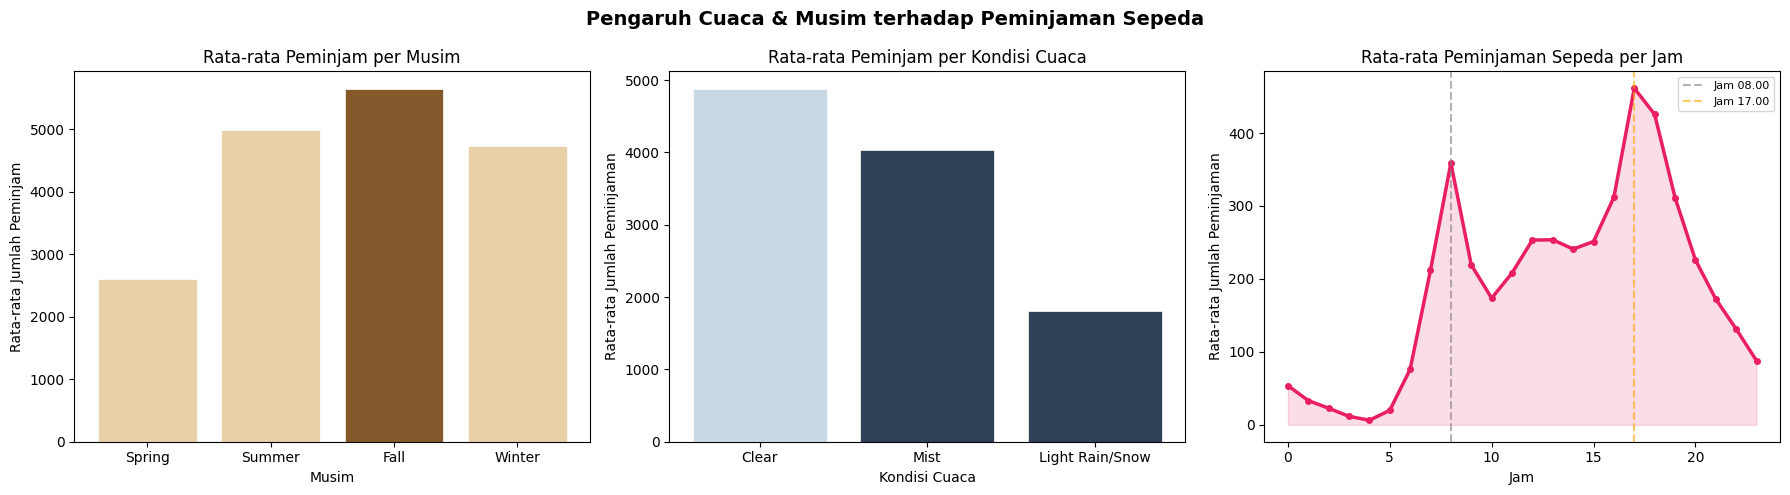

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
fig.suptitle('Pengaruh Cuaca & Musim terhadap Peminjaman Sepeda', fontsize=14, fontweight='bold')

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_avg = day_df.groupby('season_label')['cnt'].mean().reindex(season_order)
colors_season = ['#E8D1A7', '#E8D1A7', '#84592B', '#E8D1A7']
ax[0].bar(season_avg.index, season_avg.values, color=colors_season, edgecolor='white', linewidth=0.5)
ax[0].set_title('Rata-rata Peminjam per Musim')
ax[0].set_xlabel('Musim')
ax[0].set_ylabel('Rata-rata Jumlah Peminjam')
ax[0].tick_params(axis='x', labelsize=10)

weather_order = ['Clear', 'Mist', 'Light Rain/Snow']
weather_avg = day_df.groupby('weather_label')['cnt'].mean().reindex(weather_order)
colors_weather = ['#C8D9E6', '#2F4156', '#2F4156']
ax[1].bar(weather_avg.index, weather_avg.values, color=colors_weather, edgecolor='white', linewidth=0.5)
ax[1].set_title('Rata-rata Peminjam per Kondisi Cuaca')
ax[1].set_xlabel('Kondisi Cuaca')
ax[1].set_ylabel('Rata-rata Jumlah Peminjaman')
ax[1].tick_params(axis='x', labelsize=10)

hourly_avg = hour_df.groupby('hr')['cnt'].mean()
ax[2].plot(hourly_avg.index, hourly_avg.values, color='#E91E63', linewidth=2.5, marker='o', markersize=4)
ax[2].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color='#E91E63')
ax[2].axvline(x=8, color='gray', linestyle='--', alpha=0.6, label='Jam 08.00')
ax[2].axvline(x=17, color='orange', linestyle='--', alpha=0.6, label='Jam 17.00')
ax[2].set_title('Rata-rata Peminjaman Sepeda per Jam')
ax[2].set_xlabel('Jam')
ax[2].set_ylabel('Rata-rata Jumlah Peminjaman')
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('viz_pertanyaan1.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Musim Fall (gugur) memiliki rata-rata peminjaman tertinggi (5644), diikuti Summer (4992) dan Winter (4728), sementara musim Spring paling rendah (2604).
- Cuaca Clear (cerah) menghasilkan rata-rata peminjaman tertinggi (4877), sementara Light Rain/Snow menurunkan peminjaman drastis hingga 1803 yang berarti cuaca buruk mengurangi peminjaman hamoir 63% dibanding cuaca cerah.
- Terdapat dua puncak pada grafik per jam yaitu puncak pertama di jam 08.00 dan puncak kedua yang lebih tinggi di ham 17.00.
- Peminjaman terendah terjadi pada dini hari jam 02.00-04.00 yang mendekati nol, menunjukkan hampir tidak ada aktivitas di luar jam normal.

### Pertanyaan 2: Apakah terdapat perbedaab pola peminjaman antara pengguna kasual dan pengguna terdaftar berdasarkan hari kerja vs hari libur?

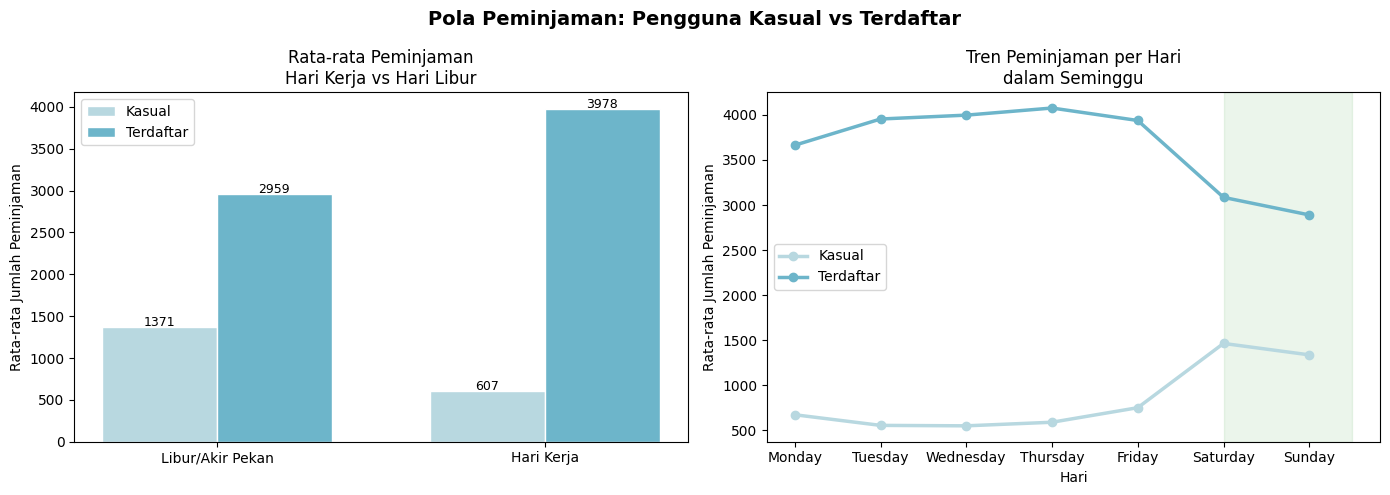

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
fig.suptitle('Pola Peminjaman: Pengguna Kasual vs Terdaftar', fontsize=14, fontweight='bold')

workday_group = day_df.groupby('workingday')[['casual', 'registered']].mean().reset_index()
workday_group['workingday'] = workday_group['workingday'].map({0: 'Libur/Akir Pekan', 1: 'Hari Kerja'})
workday_group = workday_group.set_index('workingday')

x = range(len(workday_group))
width = 0.35
bars1 = ax[0].bar([i - width/2 for i in x], workday_group['casual'], width, label='Kasual', color='#B8D8E0', edgecolor='white')
bars2 = ax[0].bar([i + width/2 for i in x], workday_group['registered'], width, label='Terdaftar', color='#6DB5CA', edgecolor='white')
ax[0].set_xticks(list(x))
ax[0].set_xticklabels(workday_group.index)
ax[0].set_title('Rata-rata Peminjaman\nHari Kerja vs Hari Libur')
ax[0].set_ylabel('Rata-rata Jumlah Peminjaman')
ax[0].legend()
for bar in bars1:
  ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{bar.get_height():.0f}', ha='center', fontsize=9)

for bar in bars2:
  ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{bar.get_height():.0f}', ha='center', fontsize=9)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = day_df.groupby('weekday_label')[['casual', 'registered']].mean()
weekday_avg = weekday_avg.reindex(weekday_order)

ax[1].plot(weekday_avg.index, weekday_avg['casual'], marker='o', color='#B8D8E0', linewidth=2.5, label='Kasual', markersize=6)
ax[1].plot(weekday_avg.index, weekday_avg['registered'], marker='o', color='#6DB5CA', linewidth=2.5, label='Terdaftar', markersize=6)
ax[1].set_title('Tren Peminjaman per Hari\ndalam Seminggu')
ax[1].set_xlabel('Hari')
ax[1].set_ylabel('Rata-rata Jumlah Peminjaman')
ax[1].tick_params(axis='x', labelsize=10)
ax[1].legend()
ax[1].axvspan(5, 6.5, alpha=0.08, color='green',label='Akhir Pekan')

plt.tight_layout()
plt.show()

**Insight:**
- Pengguna terdaftar jauh mendominasi di hari kerja (3978) dibanding hhari libur (2959), mengindikasikan penggunaan sepeda sebagai transportasi rutin.
- Sebaliknya, pengguna kasual justru lebih tinggi di hari libur (1371) dibanding hari kerja (607) dimana hal tersebut hampir 2 kali lipat, mengindikasikan penggunaan untuk rekreasi dan santai.
- Dari grafik tren mingguan, pengguna terdaftar konsisten tinggi dari hari Senin hingga Kamis (3700-4100), lalu turun signifikan di Sabtu-Minggu.
- Pengguna kasual menunjukkan pola sebaliknya yaitu rendah di hari kerja (500-600) dan melonjak tajam di Sabtu dan Minggu (1500 dan 1400).


## Analisis Lanjutan (Time Segmentation Analysis)

In [ ]:
# Bagi jam ke 4 segmen
def time_segment(hr):
    if hr >= 0 and hr < 6:
        return "Dini Hari"
    elif hr >= 6 and hr < 12:
        return "Pagi"
    elif hr >= 12 and hr < 18:
        return "Siang"
    else:
        return "Malam"

hour_df["time_segment"] = hour_df["hr"].apply(time_segment)
hour_df.groupby("time_segment")[["casual", "registered", "cnt"]].mean()

,casual,registered,cnt
time_segment,,,
Dini Hari,4.507717,20.400842,24.908559
Malam,35.305403,190.452152,225.757555
Pagi,28.978899,179.121789,208.100688
Siang,73.184000,222.299886,295.483886


In [ ]:
monthly_df = day_df.groupby(["yr", "mnth"])["cnt"].sum().reset_index()

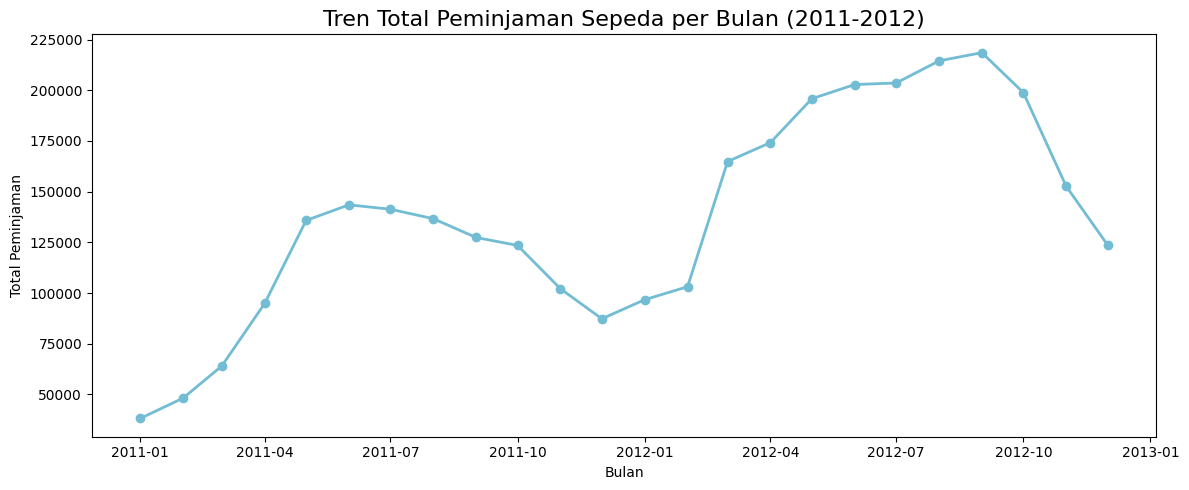

In [ ]:
monthly_df = day_df.groupby(["yr", "mnth"], as_index=False)["cnt"].sum()
monthly_df["yr"] = monthly_df["yr"].map({0: 2011, 1: 2012})
monthly_df["date"] = pd.to_datetime(
    monthly_df["yr"].astype(str) + "-" + monthly_df["mnth"].astype(str)
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_df["date"], monthly_df["cnt"],
         marker='o', linewidth=2, color="#72BCD4")
plt.title("Tren Total Peminjaman Sepeda per Bulan (2011-2012)",
          loc="center", fontsize=16)
plt.xlabel("Bulan")
plt.ylabel("Total Peminjaman")
plt.tight_layout()
plt.show()

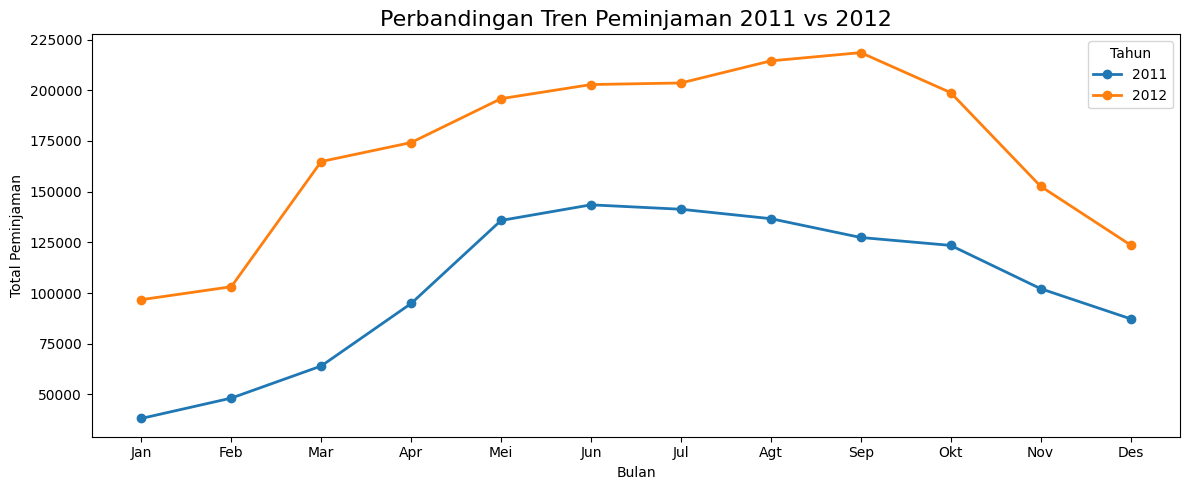

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for year, group in monthly_df.groupby("yr"):
    ax.plot(group["mnth"], group["cnt"],
            marker='o', linewidth=2, label=str(year))

ax.set_title("Perbandingan Tren Peminjaman 2011 vs 2012",
             loc="center", fontsize=16)
ax.set_xlabel("Bulan")
ax.set_ylabel("Total Peminjaman")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","Mei","Jun",
                    "Jul","Agt","Sep","Okt","Nov","Des"])
ax.legend(title="Tahun")
plt.tight_layout()
plt.show()

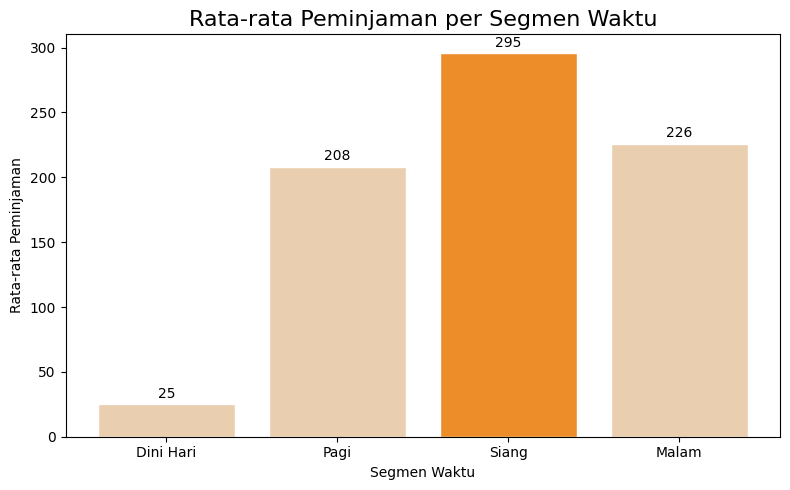

In [ ]:
segment_order = ["Dini Hari", "Pagi", "Siang", "Malam"]
segment_avg = hour_df.groupby("time_segment")["cnt"].mean().reindex(segment_order)

plt.figure(figsize=(8, 5))
colors = ["#E9CEAF", "#E9CEAF", "#ED8D2A", "#E9CEAF"]
plt.bar(segment_avg.index, segment_avg.values, color=colors, edgecolor='white')
plt.title("Rata-rata Peminjaman per Segmen Waktu",
          loc="center", fontsize=16)
plt.xlabel("Segmen Waktu")
plt.ylabel("Rata-rata Peminjaman")
for i, v in enumerate(segment_avg.values):
    plt.text(i, v + 5, f'{v:.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Conclusion

- Kesimpulan pertanyaan 1: Kondisi cuaca dan musim berpengaruh signifikan terhadap jumlah peminjaman sepeda. Musim gugur (Fall) dan cuaca cerah mendorong peminjaman tertinggi, sementara musim semi (Spring) dan kondisi hujan menghasilkan peminjaman terendah. Waktu puncak permintaan terjadi pada pukul 0.00 pagi dan 17.00-18.00 sore, yang bertepatan dengan jam berangkat dan pulang kerja. Hal ini mengindikasikan bahwa sepeda digunakan secara aktif sebagai transportasi harian.
- Kesimpulan pertanyaan 2: Terdapat perbedaan pola yang jelas antara pengguna kasual dan terdaftar. Pengguna terdaftar mendominasi di hari kerja dengan pola konsisten, sedangkan pengguna kasual meningkat tajam di akhir pekan dan hari libur (rekreasi). Temuan ini dapat dimanfaatkan untuk strategi bisnis yaitu menawarkan paket membership kepada pengguna kasual yang aktif di akhir pekan, serta memastikan ketersediaan sepeda yang cukup di jam-jam puncak komuter.